# Application laboratory: particle tracking as probabilistic matching

Two snapshots of indistinguishable particles create a natural assignment problem. If particle $a$ at the first time could have become particle $b$ at the second time with likelihood $W_{ab}$, a one-to-one assignment $\sigma$ has weight

$$
w(\sigma)=\prod_{a=1}^N W_{a,\sigma(a)}.
$$

The normalized distribution over assignments is a graphical model with hard row/column matching constraints. Its partition function is the permanent of $W$, its MAP state is a maximum-weight matching, and its edge marginals quantify uncertainty in individual particle identities.

This notebook deliberately keeps $N$ small enough to enumerate all $N!$ assignments. That gives an exact reference for the MAP and marginal calculations used later in the book.

In [1]:
CHAPTER_DIR="ch11"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / CHAPTER_DIR).exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

def save_figure(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=240, bbox_inches="tight")
    print("Saved", stem)

def draw_dark_nodes(G, pos, labels=None, ax=None, node_size=1200, arrows=False, **kwargs):
    if ax is None: ax=plt.gca()
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="#303030", edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_size=13, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)
    return ax

def annotate_heatmap(ax, image, values, fmt=".2f"):
    arr=np.asarray(values)
    lo,hi=np.nanmin(arr),np.nanmax(arr)
    mid=(lo+hi)/2
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            color="white" if arr[i,j] < mid else "black"
            ax.text(j,i,format(arr[i,j],fmt),ha="center",va="center",color=color,fontsize=11)

In [2]:
from itertools import permutations
from scipy.optimize import linear_sum_assignment

N=6
r1=np.column_stack([np.linspace(0.1,0.9,N), 0.3+0.25*np.sin(np.linspace(0,2*np.pi,N,endpoint=False))])
true_perm=RNG.permutation(N)
drift=np.array([0.10,0.05])
r2=np.empty_like(r1)
for a,b in enumerate(true_perm):
    r2[b]=r1[a]+drift+RNG.normal(scale=0.035,size=2)

sigma=0.075
d2=((r1[:,None,:]+drift-r2[None,:,:])**2).sum(axis=2)
W=np.exp(-d2/(2*sigma**2))

perms=list(permutations(range(N)))
weights=np.array([np.prod([W[a,p[a]] for a in range(N)]) for p in perms])
Z=weights.sum(); probs=weights/Z
imap=int(np.argmax(probs)); map_perm=np.array(perms[imap])
row,col=linear_sum_assignment(-np.log(W+1e-300))
assert np.array_equal(col,map_perm)

edge_marg=np.zeros((N,N))
for p,q in zip(perms,probs):
    for a,b in enumerate(p): edge_marg[a,b]+=q
print('Permanent / partition function Z =',Z)
print('true assignment:', true_perm)
print('MAP assignment :', map_perm)
print('MAP posterior probability:', probs[imap])
assert np.allclose(edge_marg.sum(0),1) and np.allclose(edge_marg.sum(1),1)

Permanent / partition function Z = 0.48405892787773364
true assignment: [4 3 1 2 5 0]
MAP assignment : [4 3 1 2 5 0]
MAP posterior probability: 0.9866655902111847


Saved ch11_01_particle_assignment


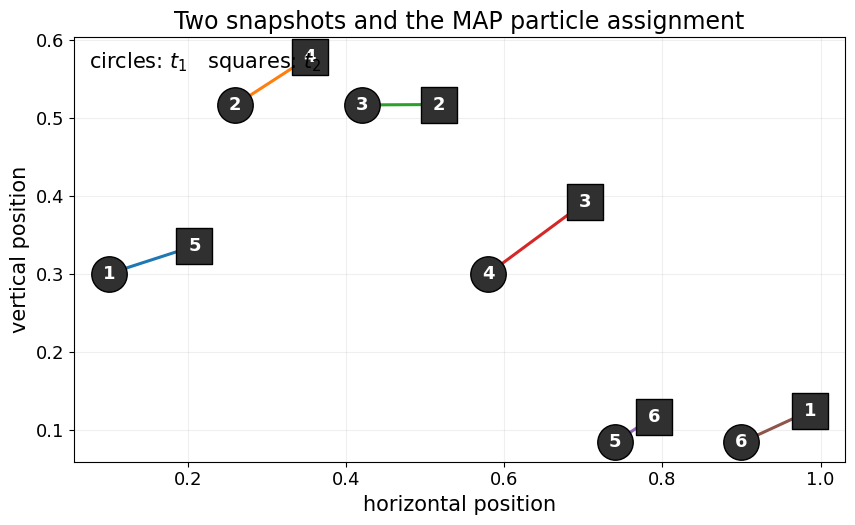

Saved ch11_01_matching_likelihood_and_marginals


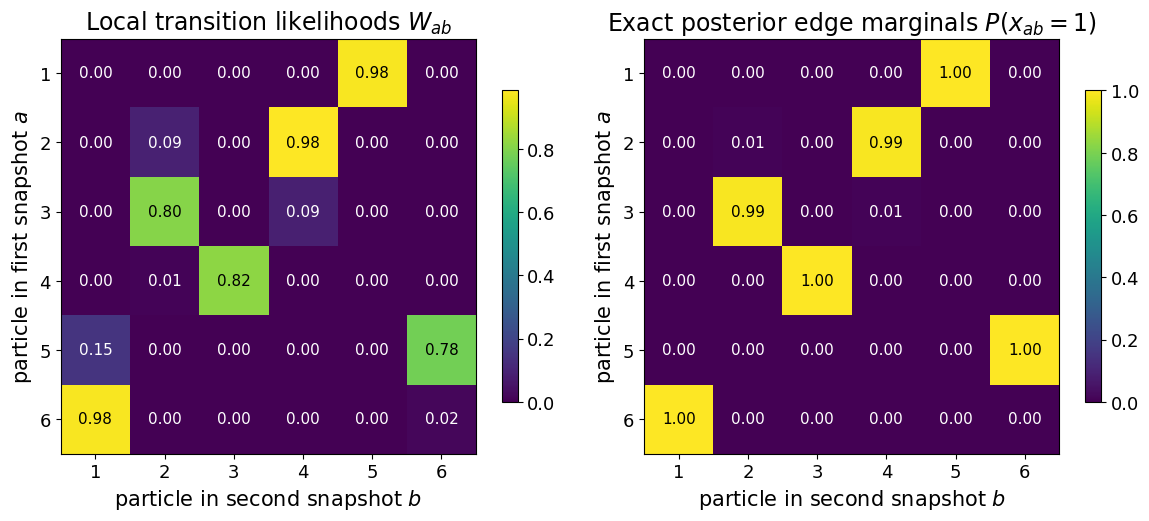

In [3]:
fig,ax=plt.subplots(figsize=(8.8,5.5))
ax.scatter(r1[:,0],r1[:,1],s=650,facecolor="#303030",edgecolor="black",zorder=3)
ax.scatter(r2[:,0],r2[:,1],s=650,facecolor="#303030",edgecolor="black",marker="s",zorder=3)
for i,(x,y) in enumerate(r1): ax.text(x,y,str(i+1),ha="center",va="center",color="white",fontsize=13,fontweight="bold")
for i,(x,y) in enumerate(r2): ax.text(x,y,str(i+1),ha="center",va="center",color="white",fontsize=13,fontweight="bold")
for a,b in enumerate(map_perm):
    ax.plot([r1[a,0],r2[b,0]],[r1[a,1],r2[b,1]],linewidth=2.2)
ax.set_title("Two snapshots and the MAP particle assignment")
ax.set_xlabel("horizontal position"); ax.set_ylabel("vertical position")
ax.text(0.02,0.97,"circles: $t_1$   squares: $t_2$",transform=ax.transAxes,va="top")
ax.grid(alpha=.2); fig.tight_layout(); save_figure(fig,'ch11_01_particle_assignment'); plt.show()

fig,axes=plt.subplots(1,2,figsize=(12,5))
im=axes[0].imshow(W)
axes[0].set_title("Local transition likelihoods $W_{ab}$")
axes[0].set_xlabel("particle in second snapshot $b$"); axes[0].set_ylabel("particle in first snapshot $a$")
axes[0].set_xticks(range(N),range(1,N+1)); axes[0].set_yticks(range(N),range(1,N+1)); annotate_heatmap(axes[0],im,W)
fig.colorbar(im,ax=axes[0],shrink=.75)
im2=axes[1].imshow(edge_marg,vmin=0,vmax=1)
axes[1].set_title("Exact posterior edge marginals $P(x_{ab}=1)$")
axes[1].set_xlabel("particle in second snapshot $b$"); axes[1].set_ylabel("particle in first snapshot $a$")
axes[1].set_xticks(range(N),range(1,N+1)); axes[1].set_yticks(range(N),range(1,N+1)); annotate_heatmap(axes[1],im2,edge_marg)
fig.colorbar(im2,ax=axes[1],shrink=.75); fig.tight_layout(); save_figure(fig,'ch11_01_matching_likelihood_and_marginals'); plt.show()

## Stress test: a stable MAP state can hide growing uncertainty

The MAP assignment in this Gaussian motion model minimizes the total squared displacement. Changing the assumed noise scale $\sigma$ rescales all assignment energies by the same positive factor, so the identity of the MAP permutation does not change. The **soft posterior**, however, changes dramatically.

This is a useful warning for later approximation chapters: a stable optimizer is not evidence that the full probability law is stable. We therefore push $\sigma$ from a sharply concentrated regime toward a nearly uniform posterior and track both the posterior entropy and the probability of the MAP assignment.

Saved ch11_01_matching_uncertainty_stress


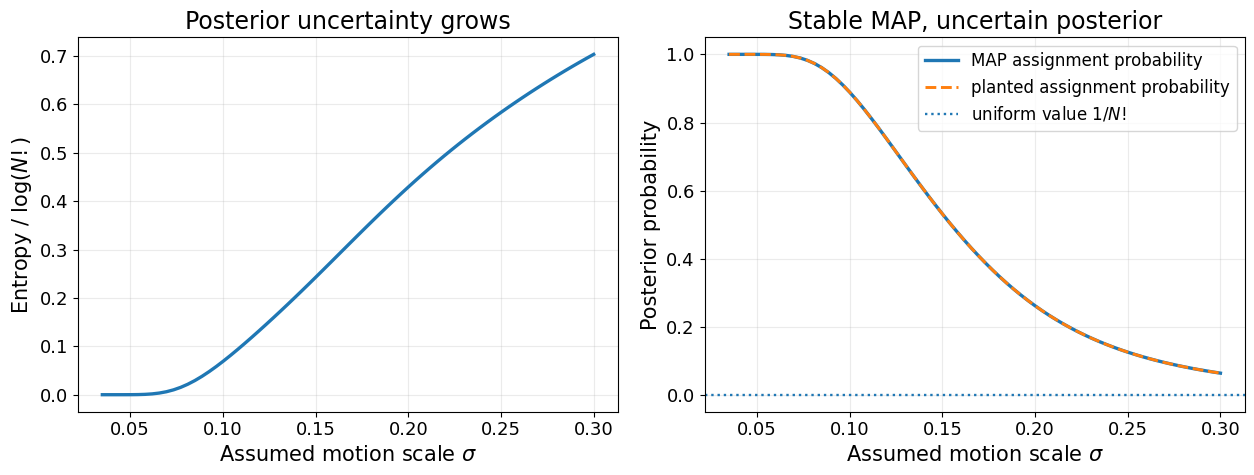

In [4]:
sigma_grid = np.linspace(0.035, 0.30, 70)
posterior_entropy = []
map_probability = []
planted_probability = []

true_index = perms.index(tuple(true_perm))
for sigma_test in sigma_grid:
    W_test = np.exp(-d2 / (2 * sigma_test**2))
    weights_test = np.array([
        np.prod([W_test[a, perm[a]] for a in range(N)]) for perm in perms
    ])
    probs_test = weights_test / weights_test.sum()
    posterior_entropy.append(-np.sum(probs_test * np.log(np.clip(probs_test, 1e-300, None))))
    map_probability.append(probs_test.max())
    planted_probability.append(probs_test[true_index])

posterior_entropy = np.asarray(posterior_entropy)
map_probability = np.asarray(map_probability)
planted_probability = np.asarray(planted_probability)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0))
axes[0].plot(sigma_grid, posterior_entropy / np.log(len(perms)), linewidth=2.4)
axes[0].set_xlabel(r"Assumed motion scale $\sigma$")
axes[0].set_ylabel(r"Entropy / $\log(N!)$")
axes[0].set_title("Posterior uncertainty grows")
axes[0].grid(alpha=0.25)

axes[1].plot(sigma_grid, map_probability, linewidth=2.4, label="MAP assignment probability")
axes[1].plot(sigma_grid, planted_probability, linestyle="--", linewidth=2.1, label="planted assignment probability")
axes[1].axhline(1 / len(perms), linestyle=":", linewidth=1.7, label=r"uniform value $1/N!$")
axes[1].set_xlabel(r"Assumed motion scale $\sigma$")
axes[1].set_ylabel("Posterior probability")
axes[1].set_title("Stable MAP, uncertain posterior")
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.tight_layout()
save_figure(fig, "ch11_01_matching_uncertainty_stress")
plt.show()

## Exercises

1. Increase the observation noise and locate the point at which the MAP assignment first differs from the planted assignment. Does the posterior reveal the ambiguity before the MAP state changes?
2. Remove one particle from the second snapshot and add one spurious detection. Reformulate the matching model with a ``null'' assignment.
3. Compare three quantities on the same instance: the MAP weight, the partition function, and the entropy of the assignment posterior. Explain why they answer different scientific questions.
4. Replace the Gaussian local likelihood by a model that also uses a noisy particle velocity. Identify which part of the graphical model changes and which hard factors remain unchanged.